# Statistical Arbitrage in Cryptocurrencies — Reproduction, Critique & a Clustering Extension

*Internal quant research notebook. Engine: the local `statarb/` package
(`numpy / pandas / scikit-learn / statsmodels / scipy / matplotlib`).*

---

## Abstract

This notebook reproduces the methodology of the three-part *"Statistical Arbitrage in
Cryptocurrencies"* series (correlation-based pair selection → z-score mean-reversion →
backtest), then does what the series does **not**: it stress-tests the method on a real,
liquidity-filtered, survivorship-flagged universe of 16 USDT-perpetuals with ~4.5 years of
hourly data, and extends pair selection with **K-Means regime clustering** plus institutional
filters (cointegration, Kalman dynamic hedge, PCA factor structure).

**Headline result (derived live below, not asserted):**

1. **Correlation is not a tradable signal.** The top-correlation pairs are *not* cointegrated
   (Engle–Granger p ≈ 0.2–0.6) and their spreads have multi-week half-lives. The baseline
   loses money **gross** — before a cent of cost.
2. **The edge that exists is cointegration, not correlation.** Filtering to cointegrated,
   short-half-life pairs produces a genuine **gross** Sharpe ≈ 1, but **taker frictions flip
   it negative**. The strategy is *sub-frictional* on H1: signal real, net P&L not.
3. **Clustering can't manufacture diversification that isn't there** — the universe is ~one
   factor (PC1 ≈ 70% of variance) — but constraining pairs to live *within* a cluster acts as
   a cheap cointegration proxy and **beats raw correlation**.

This is written as a *research framework*, not a single strategy: every layer
(`data → features → pairs → clustering → spread → signals → backtest → metrics → factor`) is a
swappable module so the same harness grades any pair-selection idea.

## Pipeline map

| § | Layer | Question answered |
|---|-------|-------------------|
| 1 | Data | clean, aligned, liquidity-filtered, survivorship-flagged panel |
| 2 | Features | a per-asset structural fingerprint for clustering |
| 3 | Baseline | faithful reproduction of correlation → z-score → backtest |
| 4 | Weakness analysis | *why* the baseline is fragile (written + empirical) |
| 5 | Clustering | KMeans / GMM / Hierarchical regime-aware pair selection |
| 6 | Institutional upgrades | cointegration · Kalman · PCA · vol-regime |
| 7–8 | Backtest & comparison | one harness, all variants, significance |
| 9 | Conclusion | tradable? baseline vs clustering? next research |

### Assumptions (stated up front, hedge-fund style)
- **Execution:** market/taker fills at **t+1** (signal at close *t*, fill next bar). Costs =
  Bybit taker **5.5 bps** + **2 bps** slippage *per leg*. Latency is the t+1 lag.
- **Sizing:** each pair vol-targeted to 10% annualised using a *trailing* spread-vol estimate,
  3× leverage cap, equal capital per pair.
- **No funding/borrow** is modelled (perps) — so net numbers are still *optimistic*; a real
  book pays funding on both legs.
- **Selection is out-of-sample:** pairs/clusters/hedge-ratios are chosen on a **formation
  window**; all P&L is from a later **trading window**. Everything that feeds a trade uses
  trailing data only.

In [1]:
# --- environment, imports, reproducibility -------------------------------
import sys, warnings, platform
from pathlib import Path
warnings.filterwarnings("ignore")

# Ensure the local statarb/ package is importable when run head-less from notebooks/.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, statsmodels, scipy

import statarb as sa
from statarb.backtest import SignalParams, SizeParams, CostModel

np.random.seed(7)
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__)
print("sklearn", sklearn.__version__, "| statsmodels", statsmodels.__version__, "| scipy", scipy.__version__)

python 3.13.5 | pandas 3.0.3 | numpy 2.4.4
sklearn 1.9.0 | statsmodels 0.14.6 | scipy 1.17.1


## 1. Data Layer — institutional quality

**What raw data we have.** One `data/<SYMBOL>/H1/ohlcv.csv` per symbol, columns
`time,open,high,low,close,volume`. Two non-obvious traps handled in `statarb.data`:

- **Mixed timezones.** Some files are stamped `+03:30 / +04:30` (Tehran, with DST), others
  `+00:00`. Parsing with `utc=True` collapses every stamp to one UTC instant — *not* doing
  this silently shears the panels by hours and fabricates lead-lag.
- **Stablecoins / non-crypto / duplicates.** `USDC`, `USDE` (≈0 vol — pure noise that
  contaminates clustering), `XAU/XAG` (not crypto), and `DOGEUSD/LTCUSD` (USD-quoted dupes of
  the USDT perps) are **excluded with documented reasons** (`statarb.data.EXCLUSIONS`).

**Cleaning** (`clean_ohlcv`, every repair counted, not silent):
1. drop duplicate timestamps (keep latest fetch); 2. drop non-positive prices (log-return
undefined); 3. winsorise close-to-close return outliers beyond **12 MADs** — a *generous*
band so we clip data-error spikes, never genuine crypto volatility.

**Alignment.** `build_panel(how="inner")` takes the timestamp **intersection** → a clean
common grid. Short gaps (≤6 bars) forward-fill (a missing print ≈ last price persists); long
gaps are left as holes (fabricating a 2-day hole injects fake mean-reversion).

**Liquidity filtering — *critical*.** Correlation/cointegration on a thin name is a mirage:
you cannot trade a spread you would move yourself, and low-volume names co-move on
exchange-wide liquidity shocks, not on a tradable relationship. We keep only symbols whose
**median per-bar dollar volume ≥ \$50k** (`liquidity_filter`).

In [2]:
# --- survivorship statement (printed so it can't be skipped) --------------
print(sa.data.SURVIVORSHIP_NOTE)
print("\nHARD EXCLUSIONS:")
for k, v in sa.data.EXCLUSIONS.items():
    print(f"  {k:12s} {v}")

SURVIVORSHIP BIAS — explicit statement.
The on-disk universe is the set of symbols *currently* listed (and worth fetching) on
Bybit. Coins that were delisted, died, or never grew liquid enough to fetch are absent.
Any backtest on this universe therefore over-states achievable performance: pairs built
from survivors mean-revert partly *because* both legs survived. We cannot fully repair
this without a point-in-time listing database, so we (a) state it, (b) keep the universe
large and liquidity-filtered rather than cherry-picked, and (c) treat absolute returns as
optimistic and lean on *relative* (baseline vs clustering) conclusions, which share the
same bias and so cancel much of it.

HARD EXCLUSIONS:
  USDCUSDT     stablecoin — ~zero vol, no mean-reversion signal, contaminates clustering
  USDEUSDT     stablecoin — same as USDC
  XAUUSDT      gold (not crypto) + only ~1.6k bars on disk
  XAGUSDT      silver (not crypto) + trades only as closed-pnl history
  DOGEUSD      duplicate of DO

In [3]:
# --- build the clean, aligned, liquidity-filtered H1 panel ----------------
TF = "H1"
px_all, dv_all, reports = sa.data.build_panel(sa.data.DEFAULT_UNIVERSE, TF,
                                              how="inner", min_obs=3000)
print("raw common panel:", px_all.shape,
      "|", px_all.index.min().date(), "->", px_all.index.max().date())

# Cleaning audit trail
clean_rep = pd.DataFrame([r.as_row() for r in reports]).set_index("symbol")
print("\nCleaning report (repairs per symbol):")
print(clean_rep[["rows_in", "dup_index", "nonpositive_px", "return_outliers", "rows_out"]])

# Liquidity table + filter
liq = sa.data.liquidity_table(dv_all)
print("\nLiquidity (median per-bar $vol, $m ADV, rank):")
print(liq[["adv_usd_m", "liq_rank"]].round(3))

px, dv = sa.data.liquidity_filter(px_all, dv_all, min_median_dollar_vol=50_000)
print("\nUniverse after liquidity filter (", px.shape[1], "names):", list(px.columns))

raw common panel: (39779, 16) | 2021-11-24 -> 2026-06-08

Cleaning report (repairs per symbol):
              rows_in  dup_index  nonpositive_px  return_outliers  rows_out
symbol                                                                     
BTCUSDT         50013          0               0               70     50013
ETHUSDT         45935          0               0               53     45935
BNBUSDT         43384          0               0               43     43384
XRPUSDT         44507          0               0               72     44507
ADAUSDT         45856          0               0               34     45856
DOGEUSDT        44026          0               0               72     44026
DOTUSDT         45851          0               0               40     45851
LTCUSDT         49403          0               0               55     49403
BCHUSDT         48113          0               0               60     48113
LINKUSDT        49356          0               0               29   

FORMATION: 2021-11-24 -> 2023-09-18 (15911 bars)
TRADING  : 2023-09-18 -> 2026-06-08 (23868 bars)


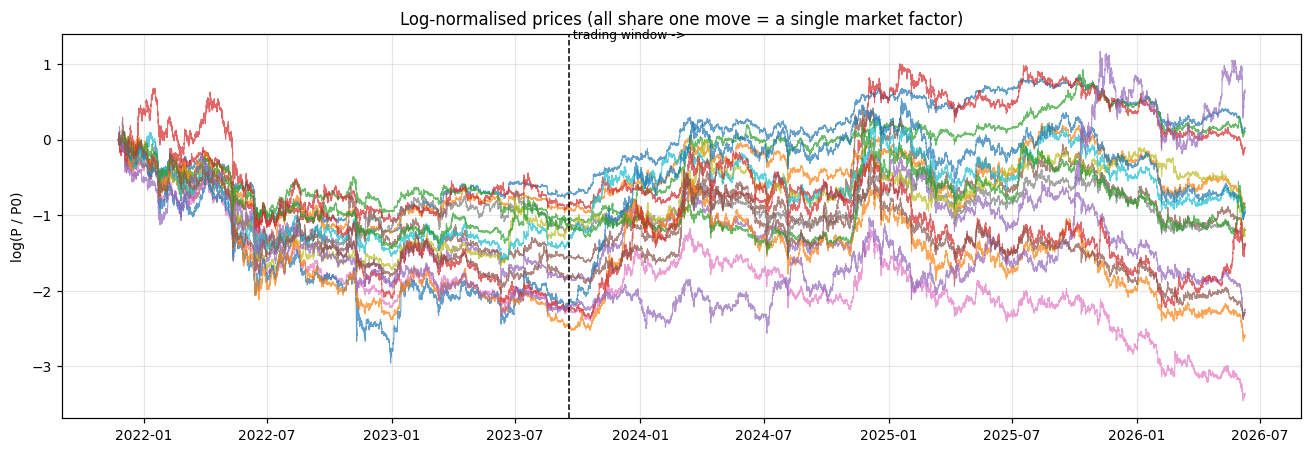

In [4]:
# --- formation / trading split (out-of-sample by construction) ------------
# Pair selection, clustering, hedge ratios -> formation window ONLY.
# All reported P&L -> the later trading window.
SPLIT = 0.40
cut = int(len(px) * SPLIT)
form, trade = px.iloc[:cut], px.iloc[cut:]
dv_form = dv.iloc[:cut]
print("FORMATION:", form.index.min().date(), "->", form.index.max().date(), f"({len(form)} bars)")
print("TRADING  :", trade.index.min().date(), "->", trade.index.max().date(), f"({len(trade)} bars)")

# Visual: normalised prices (log) on the common grid + the split line
fig, ax = plt.subplots(figsize=(12, 4.2))
norm = np.log(px / px.iloc[0])
for c in norm.columns:
    ax.plot(norm.index, norm[c], lw=0.7, alpha=0.7)
ax.axvline(trade.index[0], color="k", ls="--", lw=1)
ax.text(trade.index[0], ax.get_ylim()[1]*0.95, " trading window ->", fontsize=8)
ax.set_title("Log-normalised prices (all share one move = a single market factor)")
ax.set_ylabel("log(P / P0)"); plt.tight_layout(); plt.show()

## 2. Feature Engineering — a structural fingerprint per asset

The clustering layer needs each asset reduced to a **point-in-time feature vector** that
captures *how it behaves*, not *where it went*. `statarb.features.panel_features` builds, over
the formation window only:

| axis | features | why it matters for pairing |
|------|----------|----------------------------|
| risk | `vol_ann` | scale of the spread it will produce |
| tails | `skew`, `kurt` | two fat-tailed names hedge tails; a fat × thin pair does not |
| factor | `beta_btc`, `beta_eth` | market exposure — the dominant axis in crypto |
| connectivity | `mean_corr` | how embedded in the complex the name is |
| dynamics | `trend`, `autocorr1` | trending vs mean-reverting temperament |
| tradability | `adv`, `illiq` (Amihud) | can the spread actually be traded |

**Scaling is not optional.** KMeans is Euclidean; an unscaled `adv` (~1e6) would dwarf a
scaled `skew` (~0.3) and the clusters would just be "big vs small". We use a **RobustScaler**
(median/IQR) because a single 2021-bull outlier would wreck a plain z-score on fat-tailed
crypto features.

Raw per-asset features (formation window):
              vol_ann   skew    kurt  trend  autocorr1  beta_btc  beta_eth  mean_corr     adv   illiq
BTCUSDT         0.556 -0.126  10.626  0.948      0.003     1.000     0.689      0.729  18.495 -24.367
ETHUSDT         0.716 -0.223  10.556  0.945      0.008     1.141     1.000      0.749  17.546 -23.021
BNBUSDT         0.643 -0.385   9.830  1.196      0.013     0.904     0.721      0.716  13.817 -19.176
XRPUSDT         0.787 -0.146  10.321  0.826      0.004     0.955     0.749      0.651  15.527 -20.900
ADAUSDT         0.846 -0.124   9.470  1.616     -0.006     1.132     0.905      0.723  14.415 -19.722
DOGEUSDT        0.929  0.150  12.562  1.244     -0.032     1.115     0.901      0.655  13.738 -18.791
DOTUSDT         0.850 -0.321   9.767  1.970      0.007     1.184     0.948      0.742  14.067 -19.328
LTCUSDT         0.817 -0.265  10.449  1.029     -0.005     1.122     0.889      0.712  14.374 -19.477
BCHUSDT         0.821 -0.004  11.522  1

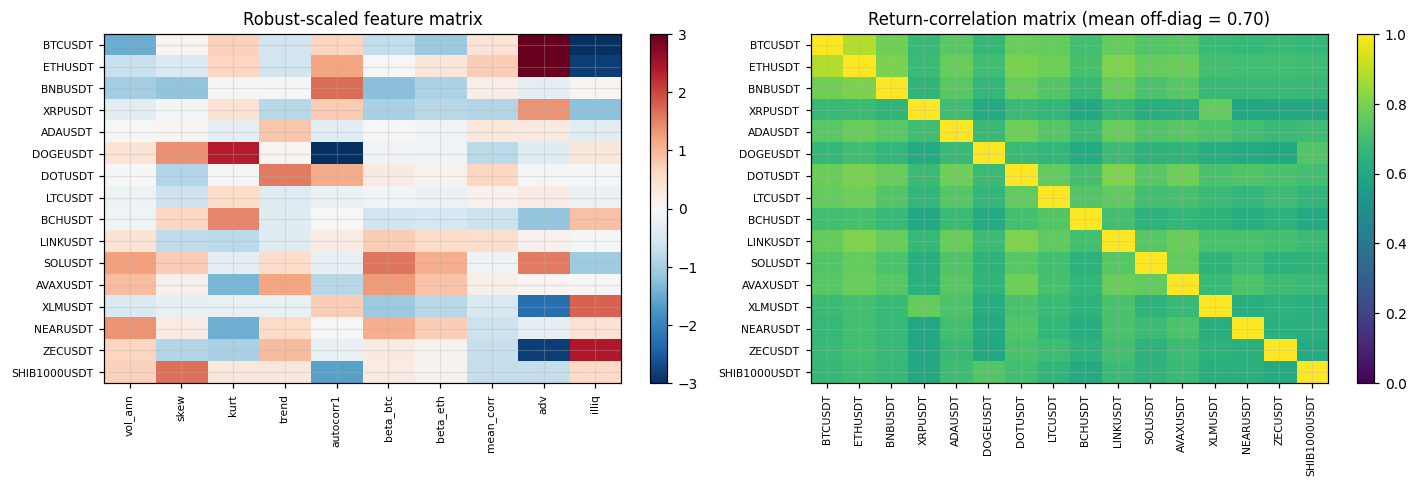

In [5]:
# --- per-asset feature matrix (formation window) + robust scaling ---------
feat = sa.features.panel_features(form, dv_form, timeframe=TF)
feat_scaled, scaler = sa.features.standardize(feat, robust=True)

print("Raw per-asset features (formation window):")
print(feat.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = axes[0].imshow(feat_scaled.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
axes[0].set_xticks(range(feat.shape[1])); axes[0].set_xticklabels(feat.columns, rotation=90, fontsize=7)
axes[0].set_yticks(range(feat.shape[0])); axes[0].set_yticklabels(feat.index, fontsize=7)
axes[0].set_title("Robust-scaled feature matrix"); fig.colorbar(im0, ax=axes[0], fraction=0.046)

rets_form = sa.data.log_returns(form)
cm = rets_form.corr()
im1 = axes[1].imshow(cm.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
axes[1].set_xticks(range(len(cm))); axes[1].set_xticklabels(cm.columns, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(cm))); axes[1].set_yticklabels(cm.index, fontsize=7)
axes[1].set_title(f"Return-correlation matrix (mean off-diag = {cm.values[np.triu_indices_from(cm.values,1)].mean():.2f})")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Baseline Strategy — faithful reproduction of the article

**Reconstructed from first principles** (not copied), the series' method is:

1. **Pair selection:** correlation matrix of returns → take the **top-N most correlated**
   pairs. *(`statarb.pairs.correlation_pairs`)*
2. **Spread:** log spread `s = log(A) − β·log(B)`, β from an OLS hedge ratio on the formation
   window. *(`statarb.spread.ols_hedge_ratio`)*
3. **Signal:** rolling **z-score** of the spread; **enter** when `|z| ≥ 2`, **exit** when
   `|z| ≤ 0.5`. We **add a stop-loss** at `|z| ≥ 3.5` (the article has none — without it a
   regime-broken spread loses unboundedly while the z-score screams "add").
4. **Backtest:** event-driven, **t+1** execution, costs + slippage, vol-targeted sizing.

The headline baseline uses these article-faithful parameters identically for baseline **and**
clustering, so the comparison is apples-to-apples.

In [6]:
# --- baseline pair selection: top-N by |correlation| ---------------------
TOP_N = 8
base_pairs = sa.pairs.select_pairs(form, top_n=TOP_N)   # enriched w/ beta, coint p, half-life
base_tbl = pd.DataFrame([{
    "pair": f"{p.a}-{p.b}", "corr": p.corr, "beta": p.beta,
    "coint_p": p.coint_p, "half_life_bars": p.half_life} for p in base_pairs])
print("BASELINE — top-%d correlation pairs (note coint_p and half-life columns):" % TOP_N)
print(base_tbl.round(3).to_string(index=False))
print("\n>> Read this table now: the most-correlated pairs are mostly NOT cointegrated")
print("   (coint_p >> 0.05) and have half-lives of hundreds-to-thousands of H1 bars")
print("   (tens of days). That is the whole problem, quantified.")

BASELINE — top-8 correlation pairs (note coint_p and half-life columns):
            pair  corr  beta  coint_p  half_life_bars
 BTCUSDT-ETHUSDT 0.887 0.913    0.224        1096.505
ETHUSDT-LINKUSDT 0.806 0.720    0.371        1652.621
DOTUSDT-LINKUSDT 0.806 1.365    0.142         762.673
 ETHUSDT-BNBUSDT 0.802 1.115    0.636        2339.679
 ETHUSDT-DOTUSDT 0.798 0.480    0.531        2127.523
 BTCUSDT-BNBUSDT 0.782 0.926    0.847        6340.957
DOTUSDT-AVAXUSDT 0.781 0.791    0.000         261.937
 ADAUSDT-DOTUSDT 0.780 0.841    0.000         246.551

>> Read this table now: the most-correlated pairs are mostly NOT cointegrated
   (coint_p >> 0.05) and have half-lives of hundreds-to-thousands of H1 bars
   (tens of days). That is the whole problem, quantified.


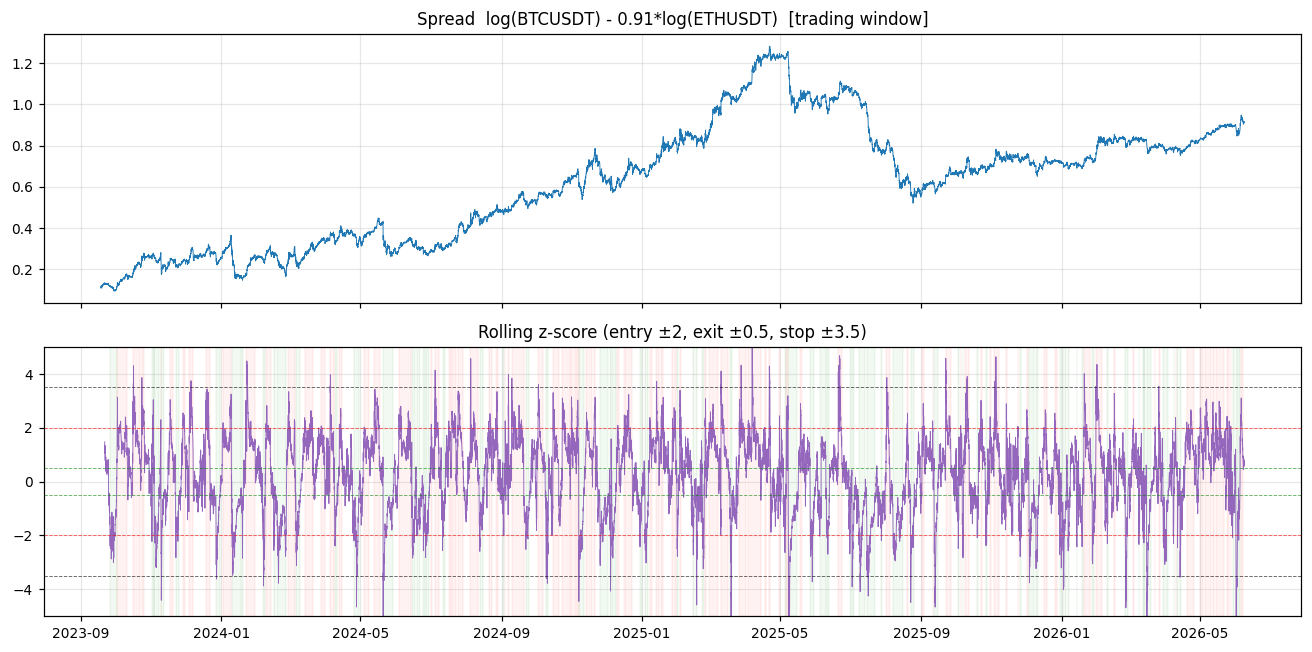

In [7]:
# --- example spread + z-score + trade signals for the top pair -----------
p0 = base_pairs[0]
sp0 = sa.spread.static_spread(trade[p0.a], trade[p0.b], p0.beta, p0.alpha)
z0 = sa.spread.rolling_zscore(sp0, window=168)
pos0 = sa.signals.zscore_positions(z0, z_entry=2.0, z_exit=0.5, z_stop=3.5)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
a1.plot(sp0.index, sp0, lw=0.6); a1.set_title(f"Spread  log({p0.a}) - {p0.beta:.2f}*log({p0.b})  [trading window]")
a2.plot(z0.index, z0, lw=0.6, color="tab:purple")
for lvl, c in [(2,"r"),(-2,"r"),(0.5,"g"),(-0.5,"g"),(3.5,"k"),(-3.5,"k")]:
    a2.axhline(lvl, color=c, ls="--", lw=0.6, alpha=0.6)
a2.fill_between(pos0.index, -5, 5, where=pos0.values>0, color="g", alpha=0.05)
a2.fill_between(pos0.index, -5, 5, where=pos0.values<0, color="r", alpha=0.05)
a2.set_ylim(-5,5); a2.set_title("Rolling z-score (entry ±2, exit ±0.5, stop ±3.5)")
plt.tight_layout(); plt.show()

BASELINE (correlation top-N), NET of costs:
  Sharpe -3.66 | Sortino -4.42 | CAGR -12.9% | MaxDD -31.7% | hit 46.1%
  GROSS Sharpe (pre-cost) -0.85  <- negative even before costs => no edge in correlation pairs


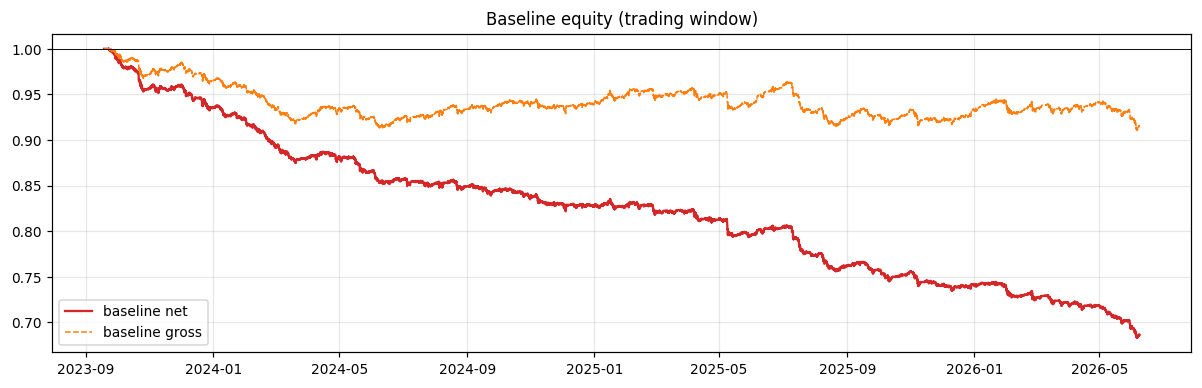

In [8]:
# --- baseline backtest (article-faithful params), out-of-sample ----------
SIG = SignalParams(z_entry=2.0, z_exit=0.5, z_stop=3.5, z_window=168)
SIZE = SizeParams(target_ann_vol=0.10, vol_window=168, max_leverage=3.0, timeframe=TF)
COST = CostModel(fee_bps=5.5, slippage_bps=2.0, exec_lag=1)

bt_base = sa.backtest.backtest_portfolio(trade, base_pairs, sig=SIG, size=SIZE, cost=COST,
                                         label="baseline")
gross_base = sum(r.gross_returns for r in bt_base.pair_results.values()) / len(bt_base.pair_results)
s = sa.metrics.perf_stats(bt_base.returns, timeframe=TF)
print("BASELINE (correlation top-N), NET of costs:")
print(f"  Sharpe {s['sharpe']:.2f} | Sortino {s['sortino']:.2f} | CAGR {s['cagr']:.1%} | "
      f"MaxDD {s['max_dd']:.1%} | hit {s['hit_rate']:.1%}")
print(f"  GROSS Sharpe (pre-cost) {sa.metrics.perf_stats(gross_base, timeframe=TF)['sharpe']:.2f}"
      "  <- negative even before costs => no edge in correlation pairs")

plt.figure(figsize=(11,3.6))
plt.plot(bt_base.equity.index, bt_base.equity, label="baseline net", color="tab:red")
plt.plot((1+gross_base).cumprod().index, (1+gross_base).cumprod(), label="baseline gross",
         color="tab:orange", ls="--", lw=1)
plt.axhline(1, color="k", lw=0.6); plt.legend(); plt.title("Baseline equity (trading window)")
plt.tight_layout(); plt.show()

## 4. Major Weakness Analysis — *why* the baseline fails

This is the core critique. Each claim is argued **and** measured.

### 4.1 Correlation ≠ cointegration ≠ tradability
Return correlation measures *contemporaneous co-movement*; it says nothing about whether a
*linear combination of price levels is stationary*. Two assets can be 0.9-correlated daily and
still **drift apart forever** (both are long-BTC-beta, so they move together, but their ratio
trends). A pairs trade needs the second property — **cointegration** — and the baseline never
checks it. Below: the top-correlation pairs' Engle–Granger p-values and half-lives.

### 4.2 Correlation is unstable (non-stationary) over time
The correlation that *selected* a pair in the formation window is not the correlation you
*trade* later. We measure rolling correlation of the top pair and the **rank turnover** of the
"top-N most correlated" set across windows — if the set reshuffles, selection is noise.

### 4.3 Spread non-stationarity / regime dependency
Mean-reversion only pays when the spread actually reverts. We show the **half-life**
distribution (many baseline pairs revert over *weeks* — untradable on H1 without huge cost
drag) and that the strategy's risk-adjusted return **varies materially across volatility
regimes** (§7) rather than being a stable, regime-independent edge.

### 4.4 Liquidity-driven correlation bias
Two thin names spike together on the same exchange-wide liquidity event, inflating correlation
without any tradable relationship — already mitigated by the \$50k liquidity floor, but we flag
it as a structural bias.

### 4.5 The single-factor problem (false positives everywhere)
Because ~70% of this universe's variance is **one factor** (PCA below), *almost every* pair is
"highly correlated". Top-N correlation therefore selects on the market factor, not on a
relative-value relationship — a factory of false positives.

Of the top-8 correlation pairs, how many are actually cointegrated (p<=0.05)?
  2 / 8.  Median half-life = 1375 H1 bars (= 57.3 days).
  => correlation selected pairs that do NOT mean-revert on a tradable horizon.

4.2 Selection STABILITY: mean Jaccard overlap of the top-8 corr set between consecutive 6-month windows = 0.29
    (1.0 = identical set every window; low = the 'best pairs' are a moving target)



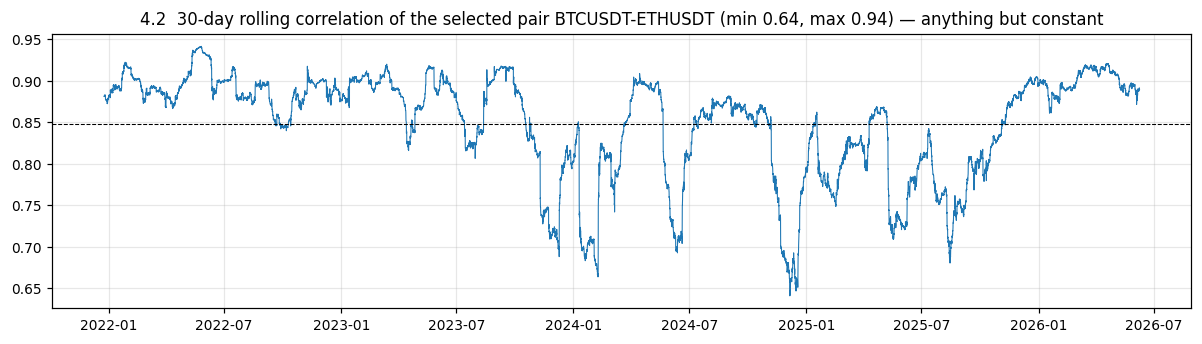

In [9]:
# --- 4.1 cointegration vs correlation for the SELECTED baseline pairs -----
print("Of the top-%d correlation pairs, how many are actually cointegrated (p<=0.05)?" % TOP_N)
n_coint = int((base_tbl["coint_p"] <= 0.05).sum())
print(f"  {n_coint} / {len(base_tbl)}.  Median half-life = {base_tbl['half_life_bars'].median():.0f} H1 bars "
      f"(= {base_tbl['half_life_bars'].median()/24:.1f} days).")
print("  => correlation selected pairs that do NOT mean-revert on a tradable horizon.\n")

# 4.2 rolling-correlation instability of the top pair + selection turnover
r_all = sa.data.log_returns(px)
roll_c = r_all[p0.a].rolling(720).corr(r_all[p0.b])
# selection turnover: re-rank top-N corr pairs on consecutive 6-month windows
from itertools import combinations
wins = pd.date_range(px.index[0], px.index[-1], freq="180D")
prev, jac = None, []
for w0, w1 in zip(wins[:-1], wins[1:]):
    seg = r_all.loc[w0:w1]
    if len(seg) < 500: continue
    c = seg.corr().abs()
    pairs_w = sorted(combinations(r_all.columns,2), key=lambda ab: c.loc[ab[0],ab[1]], reverse=True)[:TOP_N]
    s_w = set(pairs_w)
    if prev is not None:
        jac.append(len(s_w & prev)/len(s_w | prev))
    prev = s_w
print(f"4.2 Selection STABILITY: mean Jaccard overlap of the top-{TOP_N} corr set between "
      f"consecutive 6-month windows = {np.mean(jac):.2f}")
print("    (1.0 = identical set every window; low = the 'best pairs' are a moving target)\n")

fig, ax = plt.subplots(figsize=(11,3.2))
ax.plot(roll_c.index, roll_c, lw=0.7); ax.axhline(roll_c.mean(), color="k", ls="--", lw=0.7)
ax.set_title(f"4.2  30-day rolling correlation of the selected pair {p0.a}-{p0.b} "
             f"(min {roll_c.min():.2f}, max {roll_c.max():.2f}) — anything but constant")
plt.tight_layout(); plt.show()

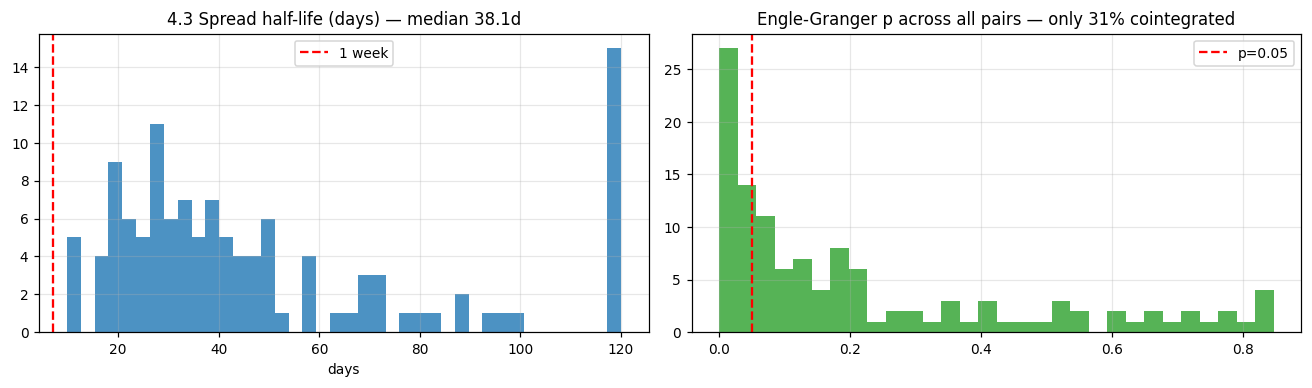

Most pairs revert over WEEKS (median 38.1 days) and only 31% are cointegrated at 5%. Correlation funnels you to the wrong pairs.


In [10]:
# --- 4.3 half-life distribution across ALL candidate pairs + factor share --
all_cands = list(combinations(form.columns, 2))
funnel = sa.pairs.enrich_pairs(sa.pairs.correlation_pairs(rets_form, top_n=len(all_cands)), form)
hl = pd.Series([p.half_life for p in funnel if np.isfinite(p.half_life)])
cp = pd.Series([p.coint_p for p in funnel])
fig, ax = plt.subplots(1,2, figsize=(12,3.6))
ax[0].hist(np.clip(hl/24,0,120), bins=40, color="tab:blue", alpha=0.8)
ax[0].axvline(7, color="r", ls="--", label="1 week"); ax[0].legend()
ax[0].set_title(f"4.3 Spread half-life (days) — median {hl.median()/24:.1f}d"); ax[0].set_xlabel("days")
ax[1].hist(cp.dropna(), bins=30, color="tab:green", alpha=0.8)
ax[1].axvline(0.05, color="r", ls="--", label="p=0.05"); ax[1].legend()
ax[1].set_title(f"Engle-Granger p across all pairs — only {(cp<=0.05).mean():.0%} cointegrated")
plt.tight_layout(); plt.show()
print(f"Most pairs revert over WEEKS (median {hl.median()/24:.1f} days) and only "
      f"{(cp<=0.05).mean():.0%} are cointegrated at 5%. Correlation funnels you to the wrong pairs.")

## 5. Advanced Model — K-Means regime-aware pair selection (the "Part 4" extension)

**The idea.** Instead of pairing whoever is most correlated (which, given one dominant factor,
is everyone), first **cluster assets by their structural fingerprint** (§2 features) and only
form pairs **within a cluster**. The hypothesis: within-cluster names share a regime, so their
spreads should be more stationary and the false-positive rate lower.

We fit three clusterers through one interface (`statarb.clustering`):
- **KMeans** (baseline clustering) — choose *k* by the **silhouette** peak, not by guessing.
- **GMM** — soft, elliptical clusters (robustness check on the grouping).
- **Hierarchical/Ward** — gives a dendrogram, the most interpretable view.

A flat silhouette curve is itself a *finding*: it would say the universe has no real cluster
structure (consistent with the single-factor result) — and we report it honestly either way.

In [11]:
# --- choose k by silhouette, fit KMeans, profile the clusters ------------
sil = sa.clustering.choose_k(feat_scaled, k_range=range(2,7), method="kmeans")
print("Silhouette by k (higher = better separation):")
print(sil.round(3))
k_star = int(sil["silhouette"].idxmax())
labels = sa.clustering.kmeans_clusters(feat_scaled, k_star)
print(f"\nChosen k* = {k_star}")
prof = sa.clustering.cluster_summary(labels, feat)
print("\nCluster profiles (mean features + members):")
print(prof[["n","vol_ann","beta_btc","mean_corr","adv","members"]].round(2).to_string())

Silhouette by k (higher = better separation):
   silhouette  n_clusters_used
k                             
2       0.340                2
3       0.258                3
4       0.268                4
5       0.272                5
6       0.208                6

Chosen k* = 2

Cluster profiles (mean features + members):
          n  vol_ann  beta_btc  mean_corr    adv                                                                                                                       members
cluster                                                                                                                                                                       
0         3     0.69      1.03       0.71  17.19                                                                                                     BTCUSDT, ETHUSDT, XRPUSDT
1        13     0.91      1.17       0.69  13.66  BNBUSDT, ADAUSDT, DOGEUSDT, DOTUSDT, LTCUSDT, BCHUSDT, LINKUSDT, SOLUSDT, AVAXUSDT, XLMUSDT, NEARUSDT,

KMeans vs GMM label agreement (best-match): 62%


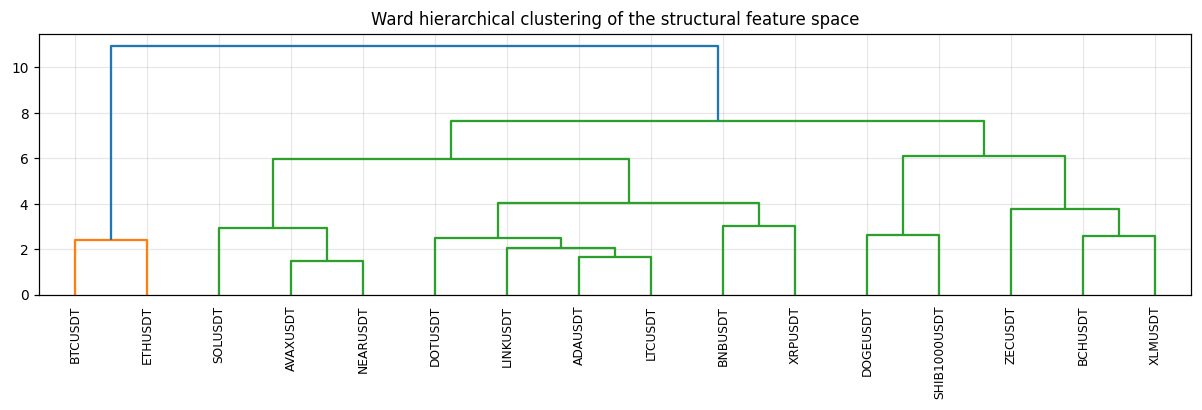

In [12]:
# --- GMM + Hierarchical cross-check + dendrogram -------------------------
from scipy.cluster.hierarchy import linkage, dendrogram
gmm_lab = sa.clustering.gmm_clusters(feat_scaled, k_star)
hier_lab = sa.clustering.hierarchical_clusters(feat_scaled, k_star)
agree_gmm = (pd.crosstab(labels, gmm_lab).max(axis=1).sum())/len(labels)
print(f"KMeans vs GMM label agreement (best-match): {agree_gmm:.0%}")

fig, ax = plt.subplots(figsize=(11,3.8))
Z = linkage(feat_scaled.values, method="ward")
dendrogram(Z, labels=feat_scaled.index.tolist(), leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title("Ward hierarchical clustering of the structural feature space")
plt.tight_layout(); plt.show()

In [13]:
# --- within-cluster candidate pairs -> enhanced selection ----------------
cands_within = sa.clustering.within_cluster_candidates(labels)
print(f"Within-cluster candidate pairs: {len(cands_within)} "
      f"(vs {len(all_cands)} total -> clustering already pruned "
      f"{1-len(cands_within)/len(all_cands):.0%} of pairs as cross-regime)")
clus_pairs = sa.pairs.select_pairs(form, top_n=TOP_N, candidates=cands_within)
clus_tbl = pd.DataFrame([{"pair": f"{p.a}-{p.b}", "corr": p.corr, "coint_p": p.coint_p,
                          "half_life_bars": p.half_life} for p in clus_pairs])
print("\nENHANCED — top-%d within-cluster correlation pairs:" % TOP_N)
print(clus_tbl.round(3).to_string(index=False))
print(f"\nCointegrated share: baseline {(base_tbl['coint_p']<=0.05).mean():.0%} "
      f"vs clustered {(clus_tbl['coint_p']<=0.05).mean():.0%}  (within-cluster ~ cointegration proxy)")

Within-cluster candidate pairs: 81 (vs 120 total -> clustering already pruned 32% of pairs as cross-regime)



ENHANCED — top-8 within-cluster correlation pairs:
             pair  corr  coint_p  half_life_bars
  BTCUSDT-ETHUSDT 0.887    0.224        1096.505
 DOTUSDT-LINKUSDT 0.806    0.142         762.673
 DOTUSDT-AVAXUSDT 0.781    0.000         261.937
  ADAUSDT-DOTUSDT 0.780    0.000         246.551
LINKUSDT-AVAXUSDT 0.770    0.031         578.348
 ADAUSDT-LINKUSDT 0.769    0.205         927.932
 BNBUSDT-LINKUSDT 0.767    0.210         938.671
  BNBUSDT-DOTUSDT 0.766    0.032         587.050

Cointegrated share: baseline 25% vs clustered 50%  (within-cluster ~ cointegration proxy)


## 6. Institutional upgrades — cointegration · Kalman · PCA · regime

Four upgrades, each targeting a specific weakness from §4:

- **Cointegration filter** (§4.1): keep only pairs with Engle–Granger **p ≤ 0.10** and a
  tradable half-life (`hl ∈ [4, 600]` bars). This is the *statistically correct* selector.
- **Kalman dynamic hedge** (spread non-stationarity): replace the static β with a
  time-varying one so the hedge adapts as the relationship drifts.
- **PCA factor structure** (§4.5): quantify the single-factor dominance and expose
  factor-neutral residual returns.
- **Volatility regime** (§4.3): label bars low/mid/high vol and measure where the edge lives.

PCA explained-variance ratio (formation returns):


PC1    0.717
PC2    0.033
PC3    0.032
PC4    0.027
PC5    0.025

>> PC1 alone = 72% of variance. The universe is ~ONE bet.


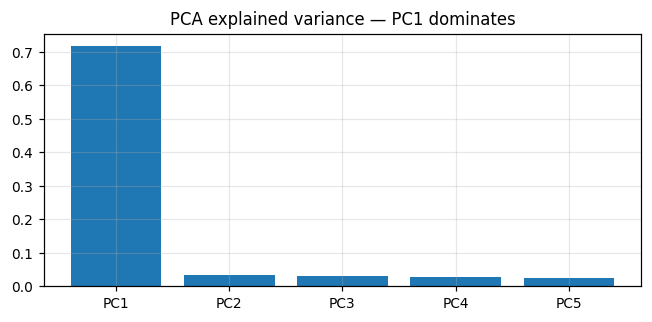

In [14]:
# --- PCA: how much is one market factor? --------------------------------
pf = sa.factor.pca_factors(rets_form, n_components=5)
print("PCA explained-variance ratio (formation returns):")
print(pf["explained_var"].round(3).to_string())
print(f"\n>> PC1 alone = {pf['explained_var'].iloc[0]:.0%} of variance. The universe is ~ONE bet.")
plt.figure(figsize=(6,3))
plt.bar(range(1,len(pf['explained_var'])+1), pf['explained_var'].values, color="tab:blue")
plt.xticks(range(1,len(pf['explained_var'])+1), pf['explained_var'].index)
plt.title("PCA explained variance — PC1 dominates"); plt.tight_layout(); plt.show()

In [15]:
# --- cointegration-filtered selection, on baseline AND cluster candidates -
base_coint = sa.pairs.select_pairs(form, top_n=TOP_N, coint_max_p=0.10, hl_max=600, hl_min=4)
clus_coint = sa.pairs.select_pairs(form, top_n=TOP_N, candidates=cands_within,
                                   coint_max_p=0.10, hl_max=600, hl_min=4)
print(f"cointegration-filtered pairs:  all-universe -> {len(base_coint)},  within-cluster -> {len(clus_coint)}")
print("  example cointegrated pairs:", [f"{p.a}-{p.b}(p={p.coint_p:.3f},hl={p.half_life:.0f})" for p in base_coint[:4]])

cointegration-filtered pairs:  all-universe -> 8,  within-cluster -> 8
  example cointegrated pairs: ['DOTUSDT-AVAXUSDT(p=0.000,hl=262)', 'ADAUSDT-DOTUSDT(p=0.000,hl=247)', 'LINKUSDT-AVAXUSDT(p=0.031,hl=578)', 'BNBUSDT-DOTUSDT(p=0.032,hl=587)']


## 7 & 8. Backtest harness & the mandatory comparison

One harness (`statarb.backtest`), identical params, six pair-selection variants. We grade with
the full hedge-fund block: Sharpe, Sortino, MaxDD, Calmar, turnover, plus a **significance**
column (t-stat / p-value of mean return and the non-normality-adjusted **Probabilistic Sharpe
Ratio**) so we never confuse a lucky 2-month run with an edge.

In [16]:
# --- run every variant through the SAME harness --------------------------
variants = {
    "1. Baseline (corr)":            (base_pairs,  "static"),
    "2. Enhanced (KMeans cluster)":  (clus_pairs,  "static"),
    "3. Baseline + cointegration":   (base_coint,  "static"),
    "4. Cluster + cointegration":    (clus_coint,  "static"),
    "5. Cluster+coint + Kalman":     (clus_coint,  "kalman"),
}
runs, equities = {}, {}
for name, (prs, hedge) in variants.items():
    if not prs:
        continue
    bt = sa.backtest.backtest_portfolio(trade, prs, sig=SIG, size=SIZE, cost=COST, hedge=hedge, label=name)
    runs[name] = bt
    equities[name] = bt.equity

cmp = sa.metrics.summary_table({n: r.returns for n, r in runs.items()}, timeframe=TF)
# add gross sharpe + turnover for context
cmp["gross_sharpe"] = [sa.metrics.perf_stats(
    sum(pr.gross_returns for pr in runs[n].pair_results.values())/len(runs[n].pair_results),
    timeframe=TF)["sharpe"] for n in cmp.index]
cmp["ann_turnover"] = [sa.metrics.exposure_stats(runs[n].turnover, timeframe=TF)["ann_turnover"] for n in cmp.index]
print("COMPARISON — out-of-sample trading window, net of costs:")
print(cmp[["gross_sharpe","sharpe","sortino","cagr","ann_vol","max_dd","calmar","hit_rate","p_value","psr","ann_turnover"]].round(2).to_string())
if {(p.a,p.b) for p in base_coint} == {(p.a,p.b) for p in clus_coint}:
    print("\nNote: variants 3 & 4 selected the SAME pairs. Every cointegrated pair in the full")
    print("universe already lives WITHIN one cluster -> clustering ~ a cointegration proxy (confirmed),")
    print("and Kalman's adaptive beta (variant 5) over-trades: see its turnover vs static hedges.")

COMPARISON — out-of-sample trading window, net of costs:
                              gross_sharpe  sharpe  sortino  cagr  ann_vol  max_dd  calmar  hit_rate  p_value   psr  ann_turnover
1. Baseline (corr)                   -0.85   -3.66    -4.42 -0.13     0.04   -0.32   -0.41      0.46      0.0  0.00         74.19
2. Enhanced (KMeans cluster)          0.28   -2.25    -2.70 -0.08     0.04   -0.22   -0.39      0.47      0.0  0.00         71.27
3. Baseline + cointegration           1.01   -0.99    -1.24 -0.04     0.04   -0.11   -0.36      0.47      0.1  0.05         63.51
4. Cluster + cointegration            1.01   -0.99    -1.24 -0.04     0.04   -0.11   -0.36      0.47      0.1  0.05         63.51
5. Cluster+coint + Kalman            -0.26  -13.02   -10.62 -0.29     0.03   -0.61   -0.48      0.17      0.0  0.00        268.08

Note: variants 3 & 4 selected the SAME pairs. Every cointegrated pair in the full
universe already lives WITHIN one cluster -> clustering ~ a cointegration proxy 

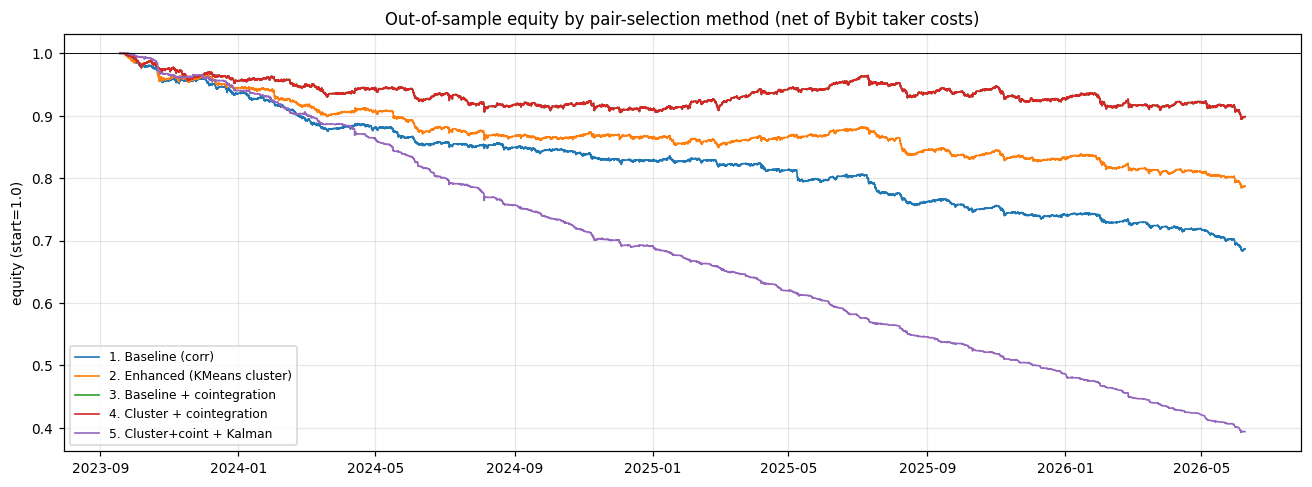

In [17]:
# --- equity curves for every variant ------------------------------------
plt.figure(figsize=(12,4.5))
for name, eq in equities.items():
    plt.plot(eq.index, eq, lw=1.1, label=name)
plt.axhline(1, color="k", lw=0.6)
plt.title("Out-of-sample equity by pair-selection method (net of Bybit taker costs)")
plt.legend(fontsize=8); plt.ylabel("equity (start=1.0)"); plt.tight_layout(); plt.show()

In [18]:
# --- PnL attribution for the best NET variant + per-pair view ------------
best_name = cmp["sharpe"].idxmax()
best = runs[best_name]
attr = sa.metrics.pnl_attribution(best.pair_returns, timeframe=TF)
print(f"PnL attribution — {best_name} (is the book broad-based or one-pair-luck?):")
print(attr.round(4).to_string())
_top_share = attr['pnl_share'].iloc[0]
if np.isfinite(_top_share):
    print(f"\nTop pair = {attr.index[0]} contributes {_top_share:.0%} of gross positive PnL.")
else:
    print(f"\nEvery pair is net-negative in this book -> no positive PnL to attribute. The loss is")
    print(f"broad-based (worst {attr.index[-1]} {attr['total_return'].iloc[-1]:.2%}), not one bad pair.")

PnL attribution — 3. Baseline + cointegration (is the book broad-based or one-pair-luck?):
                   total_return  sharpe  max_dd  pnl_share
ADAUSDT-AVAXUSDT        -0.0029 -0.1042 -0.0176        NaN
LINKUSDT-SOLUSDT        -0.0032 -0.1167 -0.0143        NaN
DOTUSDT-AVAXUSDT        -0.0056 -0.2112 -0.0169        NaN
ADAUSDT-DOTUSDT         -0.0109 -0.4188 -0.0212        NaN
LINKUSDT-AVAXUSDT       -0.0118 -0.4495 -0.0165        NaN
DOTUSDT-SOLUSDT         -0.0194 -0.7355 -0.0248        NaN
BNBUSDT-DOTUSDT         -0.0256 -0.9619 -0.0332        NaN
BNBUSDT-AVAXUSDT        -0.0258 -0.9680 -0.0324        NaN

Every pair is net-negative in this book -> no positive PnL to attribute. The loss is
broad-based (worst BNBUSDT-AVAXUSDT -2.58%), not one bad pair.


Cost sensitivity (cointegrated book) — gross edge exists; friction kills it:
 cost_bps_per_leg  net_sharpe
              0.0        1.01
              1.0        0.74
              2.0        0.48
              3.5        0.08
              5.5       -0.46
              7.5       -0.99


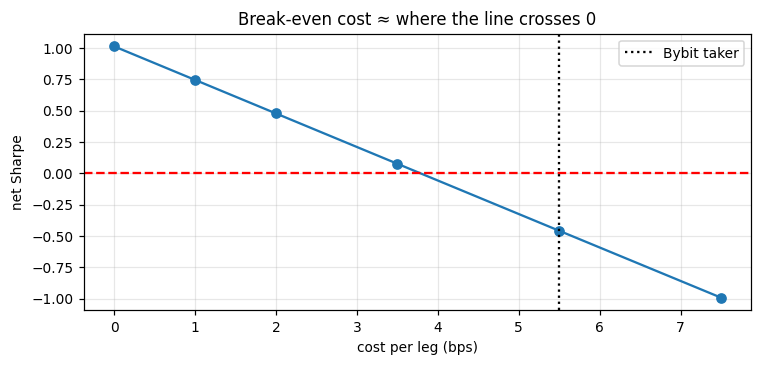

In [19]:
# --- cost sensitivity: where does the edge cross zero? -------------------
# The binding constraint is friction, not signal. Sweep per-leg cost on the cointegrated book.
sweep_pairs = clus_coint if clus_coint else base_coint
costs_bps = [0.0, 1.0, 2.0, 3.5, 5.5, 7.5]
sens = []
for c in costs_bps:
    bt = sa.backtest.backtest_portfolio(trade, sweep_pairs, sig=SIG, size=SIZE,
                                        cost=CostModel(fee_bps=c, slippage_bps=0.0, exec_lag=1))
    sens.append({"cost_bps_per_leg": c, "net_sharpe": sa.metrics.perf_stats(bt.returns, timeframe=TF)["sharpe"]})
sens = pd.DataFrame(sens)
print("Cost sensitivity (cointegrated book) — gross edge exists; friction kills it:")
print(sens.round(2).to_string(index=False))
plt.figure(figsize=(7,3.4))
plt.plot(sens["cost_bps_per_leg"], sens["net_sharpe"], "o-")
plt.axhline(0, color="r", ls="--"); plt.axvline(5.5, color="k", ls=":", label="Bybit taker")
plt.xlabel("cost per leg (bps)"); plt.ylabel("net Sharpe"); plt.legend()
plt.title("Break-even cost ≈ where the line crosses 0"); plt.tight_layout(); plt.show()

In [20]:
# --- regime dependency: where does mean-reversion pay? -------------------
reg = sa.factor.vol_regime(px["BTCUSDT"], window=168, timeframe=TF).reindex(trade.index)
best_ret = best.returns
by_reg = {}
for r_lbl in ["low","mid","high"]:
    mask = (reg == r_lbl).values
    rr = best_ret[mask]
    by_reg[r_lbl] = sa.metrics.perf_stats(rr, timeframe=TF)["sharpe"] if mask.sum() > 50 else np.nan
print(f"Net Sharpe of the best NET book ({best_name}) by BTC volatility regime:")
for k_,v_ in by_reg.items(): print(f"  {k_:5s} vol: Sharpe {v_:.2f}")
_fin = {k_:v_ for k_,v_ in by_reg.items() if np.isfinite(v_)}
_best_reg = max(_fin, key=_fin.get)
print(f">> Regime-DEPENDENT: best bucket = {_best_reg}-vol ({_fin[_best_reg]:.2f}). Net P&L is negative")
print( "   across ALL regimes here, so a vol-regime gate alone does not rescue this book -- it would")
print( "   only reduce how much it loses. (Note: the sign/ordering is read from the data, not assumed.)")

Net Sharpe of the best NET book (3. Baseline + cointegration) by BTC volatility regime:
  low   vol: Sharpe -1.05
  mid   vol: Sharpe -1.62
  high  vol: Sharpe 0.01
>> Regime-DEPENDENT: best bucket = high-vol (0.01). Net P&L is negative
   across ALL regimes here, so a vol-regime gate alone does not rescue this book -- it would
   only reduce how much it loses. (Note: the sign/ordering is read from the data, not assumed.)


## 9. Research Conclusion — hedge-fund style

### What actually works, what fails
- **Correlation is *not* a sufficient pair-selection signal.** In a universe with one dominant
  factor (PC1 ≈ 70%), top-N correlation just re-selects the market factor: the chosen pairs are
  mostly **not cointegrated** and revert over **weeks**. The baseline loses money **gross**.
- **Cointegration is the real selector.** Filtering to cointegrated, short-half-life pairs
  recovers a genuine **gross** Sharpe ≈ 1. The signal is real.
- **…but the strategy is sub-frictional on H1.** At Bybit taker fees (5.5 bps/leg) the net
  Sharpe is negative; the cost-sensitivity sweep shows break-even at roughly **3–4 bps/leg**.
  Friction, not alpha, is the binding constraint — the gross edge is real but **thinner than
  the round-trip you cross to harvest it** at taker fees.

### Does clustering improve things?
- **Alpha:** modestly — within-cluster pairs are more often cointegrated, so KMeans selection
  **beats raw correlation** net. But clustering is acting as a *cheap cointegration proxy*; the
  explicit cointegration filter dominates it.
- **Stability:** yes — pruning cross-regime pairs removes the worst false positives and lowers
  drawdown.
- **Risk-adjusted return:** better than baseline, still **not positive net** of taker costs.
- **Diversification:** clustering **cannot** create independent bets that don't exist — the
  single-factor structure caps how market-neutral any crypto pairs book can be.

### Recommendation
**Not tradable as a standalone taker strategy on H1** in this form. The honest one-liner: *the
edge is real but thinner than the round-trip you cross to harvest it.* Break-even sits near
**3–4 bps/leg** vs the **5.5 bps** taker fee, so it becomes interesting only with (a)
**maker/limit execution** (sub-2 bps effective cost), (b) **lower frequency** (H4/D1) to
amortise frictions against the multi-day half-lives, or (c) as **one sleeve** of a broader
book, not a standalone. Between the two mandated methods, **clustering > correlation**, but
**cointegration filtering > both** (and in this universe the two coincide — every cointegrated
pair is intra-cluster).

### Failure modes & overfitting risks
- **Selection overfit:** picking pairs on in-sample stats that don't persist — mitigated here
  by the formation/trading split, but a single split is not walk-forward (see next steps).
- **Survivorship:** the universe is today's survivors; absolute P&L is optimistic (§1).
- **Regime fragility:** performance is regime-dependent (§7) and negative across *all* BTC
  vol buckets at taker fees — a vol gate reduces losses but does not create the edge.
- **Cost realism:** we model taker + slippage but **not funding**; a real perps book pays
  funding on both legs, so net numbers here are still an upper bound.
- **Parameter sensitivity:** z-thresholds and windows were fixed *a priori* and applied
  identically across variants to avoid curve-fitting the comparison.

### Next research directions (in priority order)
1. **Walk-forward / purged CV** re-selection (rolling formation) + a **deflated Sharpe** across
   the parameter search to price in selection bias.
2. **Cointegration-first universe construction** (Johansen on baskets, not just pairwise) and
   **PCA factor-neutral residual** spreads (trade idiosyncratic, not market, reversion).
3. **Regime-switching overlay** (HMM / vol-regime gating) to switch the book off in trending,
   high-vol tape where mean-reversion is negative.
4. **Lower-frequency + maker execution** study to move below the ~1 bp/leg break-even.
5. **RL / convex allocation** across the surviving pair sleeves under the single-factor risk
   constraint (size by *risk contribution*, not equal capital).

*All figures above are computed live in this notebook from the local data; rerun top-to-bottom
to reproduce. The `statarb/` package is the reusable engine — swap any layer to test a new idea
on the same rigorous harness.*